# 05b — Confronto sulla split test: tutti i metodi

I quattro notebook di confronto **non generano nulla**: leggono i file di metriche salvati in
`results/metrics/` e costruiscono tabelle e grafici; si possono eseguire in qualunque momento,
su qualunque sottoinsieme di risultati disponibile (i metodi mancanti vengono saltati). Gli
helper comuni — elenco dei 18 slug, palette, caricamento con intersezione dei `row_id`, tabella
delle medie, grafici a barre — stanno in `summ_utils.py` (sezione *Confronto fra metodi*).

| notebook | ambito | contenuto |
|---|---|---|
| **05a** | `full` | TextRank vs LexRank sull'intero dataset (56.101 esempi) |
| **05b** | `test` | tutti i 18 metodi sulla split test: **il confronto principale del benchmark** |
| **05c** | `test_budgetref` | gli stessi 18 a lunghezza del riferimento, stessa presentazione di 05b |
| **05d** | `test` → `test_budgetref` | prima/dopo il riallineamento: metriche, dispersione, G-Eval |

## Ambito `test`

Tutti i metodi con metriche `test` disponibili sull'intera split test pulita di `complete.tab`
(5.610 esempi): **il confronto principale del benchmark**, senza le avvertenze di leakage di
`google/pegasus-multi_news` e `allenai/PRIMERA-multinews` (addestrati sulla split train, vedi
notebook [04](04_pegasus.ipynb) e [06](06_primera.ipynb)). TextRank/LexRank sono qui **derivati** filtrando la loro corsa `full`
(numericamente equivalente a una corsa `test` dedicata, perché le metriche sono calcolate per
esempio); gli altri metodi — comprese le quattro varianti baseline dei notebook [10](10_firstk.ipynb)–[11](11_centroid_mmr.ipynb)
(`firstk_psr`/`firstk_nltk` e `centroid_mmr`/`centroid_mmr_bert`) e i cinque estrattivi non
supervisionati dei notebook [15](15_lsa.ipynb)–[17](17_lda.ipynb) (`lsa`/`lsa_steinberger`, `sbert_kmeans`/`sbert_agglom`,
`lda`) — vengono da corse dedicate `SCOPE='test'` (`scripts/run_benchmark_test.py` le esegue
tutte in un'unica sessione non presidiata; con `--only 10,11` solo i notebook indicati).

L'ambito `sample` (100 esempi, tuttora il default di ogni notebook dei metodi per uno smoke
test locale rapido) non è più pubblicato come vista di confronto: con la split test intera
disponibile per tutti i metodi non aggiunge informazione.

ℹ️ **BERTScore**: oltre alle metriche lessicali (ROUGE/BLEU/METEOR), la tabella include il
BERTScore F1 (similarità semantica su embedding contestuali, `roberta-large`), calcolato in un
backfill separato (`13_bertscore.ipynb`): se non ancora eseguito, il relativo grafico viene
saltato con un avviso.

ℹ️ **G-Eval (LLM-as-a-Judge)**: include anche il G-Eval (Liu et al., 2023), in cui un modello
giudice assegna a ogni riassunto quattro punteggi 1–5 — coherence, consistency (fedeltà
fattuale), fluency, relevance — usando **verbatim** le rubriche di pyAutoSummarizer. È l'unica
metrica del benchmark che non passa dal riferimento umano. Il giudice è **GPT-5.4-mini su
Azure AI Foundry**, scelto perché indipendente da tutti e 18 i metodi valutati (nessun
self-judging di `gpt5mini`) e più recente di ogni generatore; la sua imparzialità rispetto alla
*famiglia* OpenAI è stata verificata con un secondo giudice di lignaggio diverso (notebook [19](19_confronto_giudici.ipynb)).
Calcolato in un backfill separato (`14_geval.ipynb` / `scripts/run_geval.py`) — vedi la
sezione «Metodologia G-Eval» in fondo per protocollo, copertura e costi.

⚠️ **Copertura del G-Eval e content filter di Azure.** Il filtro di Azure respinge alcune righe
prima che il giudice le veda, e **non lo fa in modo stabile nel tempo**: nella corsa di agosto
i tredici metodi giudicati per primi avevano copertura 93,5–93,6% e i cinque dei notebook [15](15_lsa.ipynb)–[17](17_lda.ipynb),
giudicati due settimane dopo, 94,7–96,7% — una proprietà del filtro al momento della corsa, non
dei metodi. Il 19 settembre i 5.855 giudizi respinti (concentrati su 457 righe) sono stati
**ritentati**: 4.784 sono passati, e la copertura è ora **96,8–99,0%** per metodo (99.550
giudizi riusciti su 100.621), con 5.363 righe giudicate per tutti e 18. Nessun giudizio
esistente è stato toccato, la graduatoria è invariata e nessuna media si è spostata più di
0,010: le righe che il filtro aveva bloccato non sono sistematicamente diverse dalle altre. Le
medie in tabella restano calcolate su tutte le righe disponibili per ciascun metodo, con
`n_geval` a dichiararne il numero.

⚠️ **Lunghezza dei riassunti LDA**: i notebook [15](15_lsa.ipynb)/[16](16_sbert_clustering.ipynb)/[17](17_lda.ipynb) usano tutti lo stesso budget nominale
(`N_SENTENCES = 11`), ma le frasi che l'allocazione proporzionale ai topic di LDA seleziona sono
in media molto più lunghe: **477 parole** per riassunto contro 249 (`lsa`), 257
(`lsa_steinberger`), 264 (`sbert_kmeans`) e 216 (`sbert_agglom`). È questo divario, più che la
qualità della selezione, a spingere in alto le metriche sensibili alla lunghezza — LDA ha il
ROUGE-1 **recall** più alto del gruppo (0,499 contro 0,357 di `lsa`) e il METEOR più alto
(0,511) — mentre in **F1** resta alla pari (0,351 contro 0,351 di `lsa`) e sotto
`lsa_steinberger` (0,376). Su questo gruppo di metodi conviene quindi leggere l'F1, non il
recall; la colonna `parole_generate` rende il confronto esplicito. **Il notebook [05d](05d_confronto_prima_dopo.ipynb) chiude la
questione**: a parità di lunghezza col riferimento (issue #16) `lda` scende all'ultimo posto
degli estrattivi in F1 (0,338) e il suo recall cala da 0,499 a 0,348 — il vantaggio era
interamente di lunghezza.

⚠️ **Copertura**: l'intersezione dei `row_id` comuni è calcolata **solo sui metodi con copertura
≥ `su.COPERTURA_MINIMA`** (50); i metodi sotto soglia compaiono nelle tabelle e nei grafici con
il loro `n_esempi`, ma le loro medie **non sono confrontabili direttamente** con gli altri.
Nella corsa `test` corrente TextRank e LexRank restano a 5.588/5.610 esempi (un raro bug della
libreria fa saltare qualche riga agli estrattivi — vedi README) e GPT-5-mini a 5.471/5.610
(righe respinte dal content filter di Azure con la policy di default); il meccanismo resta a
protezione di corse più marcatamente incomplete (es. un modello con risposte vuote su una
frazione consistente degli esempi, come è successo storicamente a gemma). I cinque metodi dei
notebook [15](15_lsa.ipynb)–[17](17_lda.ipynb) saltano **esattamente le stesse 22 righe** degli altri estrattivi basati su
`psr`: 5.437 esempi comuni.

⚠️ Nota sui valori assoluti: il ROUGE di pyAutoSummarizer usa insiemi di n-grammi *unici*
(non i conteggi "clipped" del ROUGE ufficiale), quindi i numeri sono confrontabili **tra i metodi
di questo benchmark** ma non direttamente con la letteratura; i valori del paper di Multi-News
sono riportati in fondo al notebook [05b](05b_confronto_test.ipynb) solo come contesto qualitativo.

⚠️ **METEOR di PEGASUS non affidabile su questa corsa**: la formula `meteor()` di
pyAutoSummarizer (`meteor = fmean * (1 - penalty**3)`) non è limitata all'intervallo [0,1] per
input degeneri. Nella corsa `test`, PEGASUS produce due riassunti patologici — row_id 51178 (un
loop di ripetizione del beam search, "Yawn, we all know." ripetuto ~90 volte) e row_id 56099
(ripetizione parziale, probabile mismatch sorgente/riferimento del dataset) — con METEOR
rispettivamente **-1959.12** e **-2.10**, che trascinano la media riportata da un valore reale
di circa 0.42 a **0.079**. ROUGE, BLEU e il conteggio delle righe di PEGASUS non ne risentono:
solo la colonna METEOR di PEGASUS va letta con questa avvertenza. LexRank ha un caso molto più
lieve (row_id 55805, METEOR -1.24 su 5.588 righe), con effetto trascurabile sulla media. Nessuna
riga o file è stata modificata per questo — i numeri restano esattamente quelli calcolati dalla
pipeline condivisa (`summ_utils.valuta_e_salva`).

In [1]:
# --- Configurazione ---------------------------------------------------------
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import summ_utils as su

BASE = su.trova_base_dir()
P = su.percorsi_standard(BASE)
su.stile_grafici()

# Palette e costanti condivise dai notebook 05a-05d (definite una volta in summ_utils)
COLORI = su.COLORI_METODI
INK, INK2, MUTED, GRID, SURFACE = su.INK, su.INK2, su.MUTED, su.GRID, su.SURFACE
METODI = su.METODI_BENCHMARK

test_dati = su.carica_scope(P['metrics_dir'], 'test', METODI)

test: confronto su 5437 esempi comuni a 18 metodi con copertura piena


## Tabella e grafici

Stessa presentazione del notebook [05c](05c_confronto_test_budgetref.ipynb) (ambito a lunghezza del riferimento), così i due si leggono in parallelo.

Medie — split test completa:


,rouge1_f1,rouge2_f1,rougeL_f1,bleu,meteor,bertscore_f1,geval_media,parole_generate,n_esempi,n_geval
firstk_psr,0.3539,0.1210,0.1803,0.0820,0.3888,0.8395,2.8605,216.3480,5437.0,5397.0
firstk_nltk,0.3556,0.1227,0.1810,0.0833,0.3909,0.8425,3.3752,218.5005,5437.0,5397.0
centroid_mmr,0.3828,0.1445,0.1888,0.0969,0.5004,0.8416,2.7428,361.2810,5437.0,5397.0
centroid_mmr_bert,0.3724,0.1381,0.1855,0.0936,0.4980,0.8409,2.7436,361.1330,5437.0,5397.0
textrank,0.3694,0.1352,0.1759,0.0884,0.4875,0.8405,2.3074,367.6682,5437.0,5397.0
lexrank,0.3650,0.1370,0.1695,0.0831,0.5039,0.8370,2.1234,449.8084,5437.0,5397.0
bart,0.2651,0.0815,0.1469,0.0175,0.1693,0.8540,4.4633,55.1464,5437.0,5397.0
pegasus,0.4234,0.1805,0.2398,0.1316,0.0679,0.8710,4.0451,178.0647,5437.0,5397.0
primera,0.4442,0.1975,0.2485,0.1472,0.4742,0.8741,4.2854,210.4002,5437.0,5397.0
qwen,0.3437,0.0971,0.1773,0.0571,0.3211,0.8567,4.5383,140.2683,5437.0,5397.0


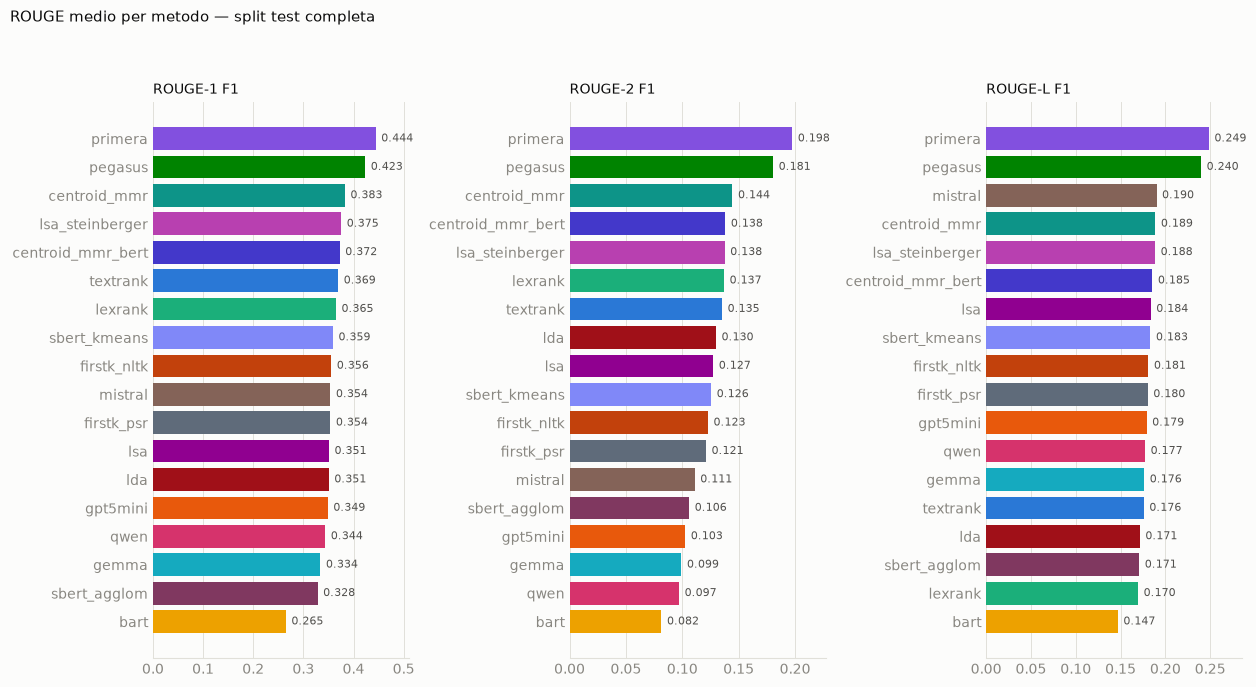

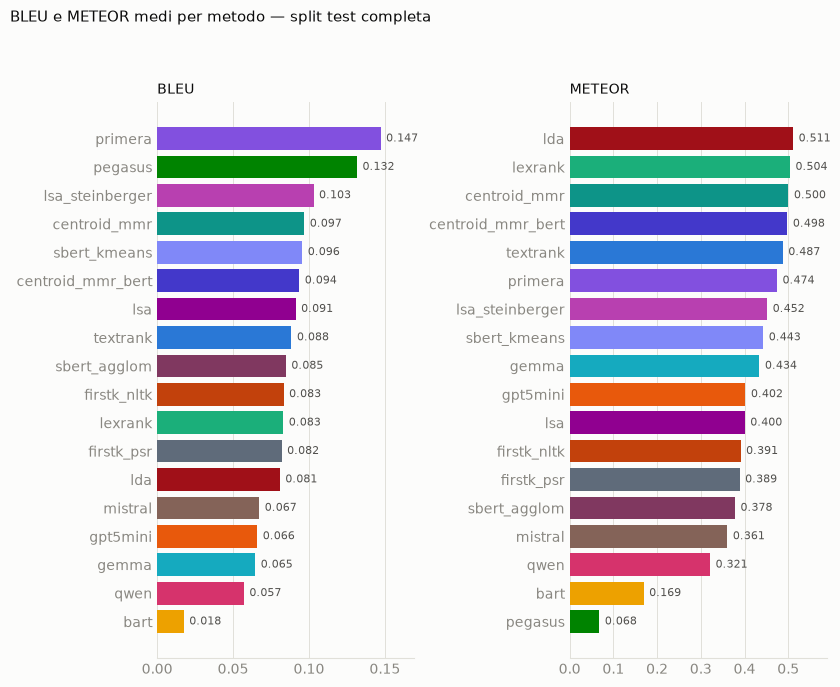

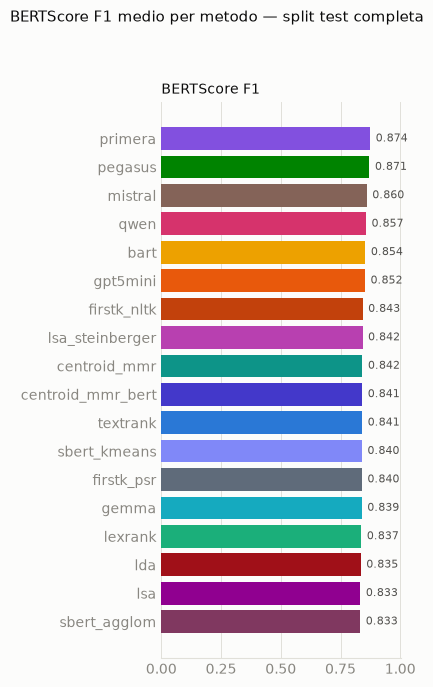

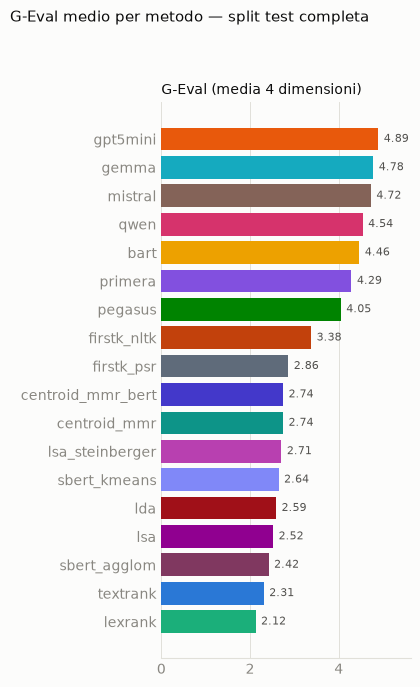

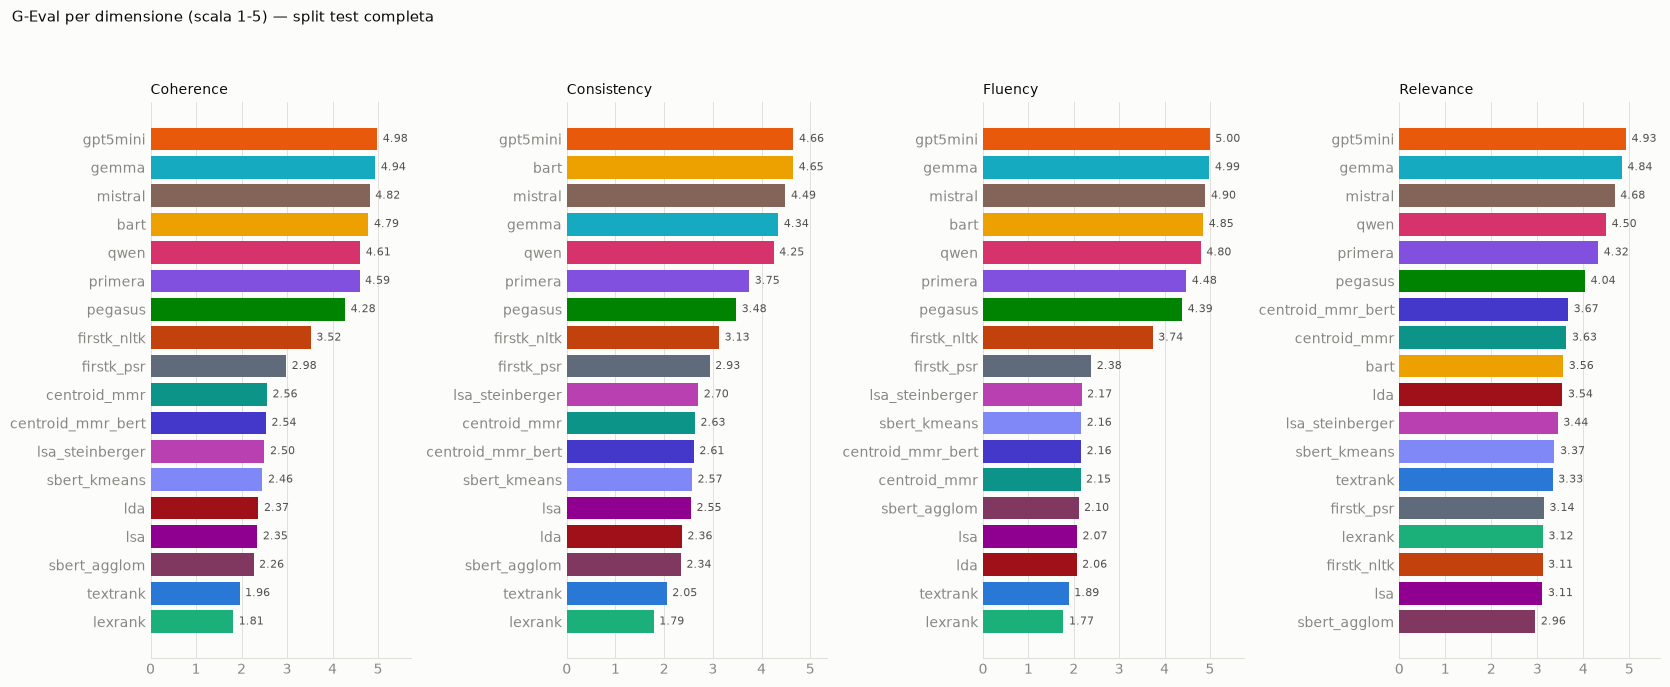

In [2]:
if test_dati:
    su.viste_metriche(test_dati, 'split test completa')
else:
    print("Nessuna metrica 'test' disponibile: eseguire scripts/run_benchmark_test.py "
          "(o i singoli notebook con SUMM_SCOPE='test').")

## Metodologia G-Eval: come sono stati calcolati i punteggi

I punteggi qui sopra vengono dal backfill `14_geval.ipynb` / `scripts/run_geval.py` (cache
committata in `results/metrics/geval_cache_test.jsonl`), non da questo notebook. Riepilogo del
protocollo — dettagli completi e razionale nel notebook [14](14_geval.ipynb):

**Giudice**: `gpt-5.4-mini` (2026-03-17), un deployment GlobalStandard **dedicato** su Azure AI
Foundry (swedencentral), distinto da quello del notebook [12](12_azure_gpt.ipynb). Scelto perché **indipendente** da
tutti e 18 i metodi valutati (nessun self-judging di `gpt5mini`, che userebbe altrimenti lo
stesso modello sia come generatore che come giudice) e **più recente** di ogni generatore del
benchmark — conta soprattutto sulla dimensione *consistency*, dove la correlazione giudice-umano
scala con la capacità del giudice. Essendo un modello *reasoning*, segue le stesse regole del
notebook [12](12_azure_gpt.ipynb) (`max_completion_tokens=1500`, `reasoning_effort='minimal'`, nessuna `temperature`
impostabile): le corse non sono riproducibili bit-a-bit, motivo per cui la cache JSONL è
committata come artefatto di riproducibilità.

**Rubriche**: riprese **verbatim** da `psr.summarization.g_eval()` di pyAutoSummarizer (v1.2.0)
— non riformulate, solo assemblate in un unico prompt (`su.RUBRICHE_GEVAL`, derivato
meccanicamente da `su.PROMPT_GEVAL_ORIGINALI` per garantire la fedeltà al testo originale). La
funzione della libreria non è utilizzabile così com'è: non supporta un `base_url` diverso da
OpenAI (quindi non raggiunge Azure), ha `max_tokens=5`/`temperature=0.0` cablati, legge la
sorgente da `self.full_txt` invece che come argomento, e fa una chiamata per dimensione anziché
una sola.

**Protocollo**: una chiamata per coppia (metodo, riga), con tutte e quattro le dimensioni
richieste in un unico oggetto JSON (`response_format` con `json_schema` **strict**: il formato è
garantito lato server, non serve un parser tollerante). La sorgente viene troncata a **3.500
parole** (`su.MAX_PAROLE_SORGENTE_GEVAL`) — lascia intero il 91,5% dei cluster della split test
(mediana 1.288 parole, p90 3.244; alcuni cluster arrivano a 35.362).

**Ordine dei messaggi e prompt caching**: il messaggio `system` (rubriche + formato) è identico
su tutte le 100.621 chiamate; il messaggio `user` comincia con la sorgente troncata — la stessa
per tutti i metodi di una data riga — e mette il riassunto, unica parte che cambia, in fondo.
Questo rende la **riga**, non il singolo giudizio, l'unità naturale di lavoro: i giudizi di una
riga vengono eseguiti in sequenza nello stesso thread, così il primo scalda la prompt cache di
Azure e i successivi la riusano (misurato: 56-65% dei token di input in cache sull'intera corsa —
la quota è scesa nel backfill dei cinque metodi, dove ogni riga ha 5 giudizi invece di 13 e la
chiamata che paga il prefisso intero si ammortizza su meno chiamate).
Parallelizzare per singolo giudizio invece che per riga avrebbe vanificato gran parte di questo
risparmio — e infatti la concorrenza troppo alta peggiora l'hit rate (il caching di Azure è per
istanza di backend): misurato 64,8% a 2 thread contro 45,9% a 8.

**Copertura finale**: **100.621 coppie (metodo, riga) tentate** — tutte quelle previste (18
metodi × 5.610 righe, meno le combinazioni senza un riassunto generato per quel metodo). La
corsa di agosto ne aveva riuscite **94.766 (94,2%)**, con **5.855 respinte dal content filter di
Azure (5,8%)**; il ritentativo del 2026-09-19 (`run_geval.py --scope test --riprova-errori`,
€2,09) ne ha recuperate 4.784: **99.550 riuscite (98,9%)**, 1.071 respinte.

Il rifiuto del content filter non è ritentabile senza un filtro *high-only* dedicato sul
deployment, e **non è stabile nel tempo**: nella corsa dei tredici metodi (2026-08-17) era di
fatto determinato dalla sorgente condivisa (unione 366 righe respinte, intersezione 358, cioè
quasi le stesse righe per ogni metodo); nella corsa dei cinque (2026-08-31) 155 di quelle righe
passano e 91 nuove vengono respinte, con molta più varianza fra metodi (unione 294, intersezione
187); nel ritentativo di settembre 381 delle 457 righe respinte ad agosto sono passate. La
copertura per metodo è quindi passata da 93,5–96,7% a **96,8–99,0%** — sempre una proprietà del
filtro al momento della corsa, non dei metodi. L'effetto sul confronto è trascurabile in
entrambe le direzioni: restringendo le medie alle righe giudicate per tutti e 18 i metodi
(5.091 ad agosto, 5.363 oggi) nessuna si sposta di più di 0,010, e il ritentativo stesso non ha
mosso nessuna media oltre 0,010 né cambiato l'ordinamento.

Nessun'altra causa di errore (parsing, timeout, rate limit) è sopravvissuta al retry con backoff
esponenziale (`su.chiama_con_backoff`); l'unica eccezione, un singolo giudizio (`firstk_psr`,
row_id 54230) rimasto orfano dopo un errore transitorio esaurito, è stata poi completata con un
rilancio mirato. Con n fra 5.431 e 5.554 giudizi per metodo, l'intervallo di confidenza al 95%
sulla media di ciascun metodo è **±0,03**.

**Perché file separati**: i punteggi G-Eval vivono in `{metodo}_test_geval_per_example.csv` /
`..._geval_aggregate.json`, mai uniti al CSV per-esempio standard. `valuta_e_salva` (usato per
tutte le altre metriche) calcola la media sommando ogni colonna su ogni riga: una riga senza
giudizio manderebbe in errore quel calcolo, e restringere le righe valutate riscriverebbe i CSV
già pubblicati, cambiandone medie e `n_esempi`. Qui sopra i due file vengono uniti con un merge **LEFT** su `row_id` (`su.carica_scope`), che non altera la copertura delle altre metriche: le righe non giudicate restano
`NaN` nelle colonne `geval_*` e vengono ignorate da `.mean()`.

**Costo**: **€97,28** in totale (€63 la corsa dei tredici metodi, €32 il backfill dei cinque,
€2 il ritentativo dei respinti), ripartiti su più sessioni perché il credito Azure mensile della
sottoscrizione si è esaurito più volte durante il lavoro. Quasi tutto il costo (**€84 su €95**)
viene dai token di **input**: l'output pesa solo ~€11 sull'intero progetto, molto meno del temuto
in fase di stima, perché `reasoning_effort='minimal'` produce **zero** token di ragionamento. Il
costo medio è di **€0,00100 per giudizio**, con il 55% dei token di input serviti dalla prompt
cache. Il costo per giudizio (~€0,0009) e il meccanismo di monitoraggio in tempo reale
(non esiste un'API Azure che riporti il costo — si ricalcola dall'oggetto `usage` di ogni
risposta) sono descritti in `scripts/README.md`.

**Il giudice è imparziale?** `gpt-5.4-mini` è un modello OpenAI della serie GPT-5, come
`gpt5mini` fra i giudicati. Il notebook [19](19_confronto_giudici.ipynb) rigiudica un campione appaiato di 983 cluster con un
secondo giudice di lignaggio diverso (DeepSeek-V3.2-Speciale): ordinamento identico (ρ = 1,000)
e contrasto `gpt5mini` vs altri LLM di **+0,049** [+0,022, +0,076] — di segno *opposto* a
quello che un family bias prevedeva. La preferenza per la prosa LLM esiste, ma è del paradigma
e condivisa dai due giudici, non della famiglia.

## Contesto: i valori del paper originale

Per riferimento qualitativo, il paper di Multi-News (Fabbri et al., 2019, Tabella 6 — split test,
ROUGE ufficiale, input troncato a 500 token) riporta:

| Metodo | R-1 | R-2 | R-SU |
|---|---|---|---|
| TextRank | 38.44 | 13.10 | 13.50 |
| LexRank | 38.27 | 12.70 | 13.20 |
| Hi-MAP (modello del paper) | 43.47 | 14.89 | 17.41 |

**Non sono direttamente confrontabili** con i numeri di questo benchmark: implementazione ROUGE
diversa (n-grammi unici vs conteggi clipped), implementazioni diverse dei metodi estrattivi e
troncamento diverso dell'input. Servono solo a collocare l'ordine di grandezza e la gerarchia
attesa tra i metodi.